In [31]:
# LOAD DATA
import pandas as pd

df = pd.read_csv("healthcare_processed.csv")

# BASIC CHECK
print("Columns:", df.columns)
print("Shape:", df.shape)

# ENSURE DATES & FEATURES
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

if "Length of Stay" not in df.columns:
    df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

# CREATE IDS

df["patient_id"] = df["Name"].astype("category").cat.codes
df["hospital_id"] = df["Hospital"].astype("category").cat.codes
df["doctor_id"] = df["Doctor"].astype("category").cat.codes
df["condition_id"] = df["Medical Condition"].astype("category").cat.codes
df["medication_id"] = df["Medication"].astype("category").cat.codes

# CREATE TABLES

patients = df[["patient_id", "Age", "Gender", "Blood Type"]].drop_duplicates()

hospitals = df[["hospital_id", "Hospital"]].drop_duplicates()

doctors = df[["doctor_id", "Doctor"]].drop_duplicates()

medical_conditions = df[["condition_id", "Medical Condition"]].drop_duplicates()

medications = df[["medication_id", "Medication"]].drop_duplicates()

df["record_id"] = range(len(df))

medical_records = df[[
    "record_id",
    "patient_id",
    "hospital_id",
    "doctor_id",
    "condition_id",
    "medication_id",
    "Admission Type",
    "Billing Amount",
    "Test Results",
    "Date of Admission",
    "Discharge Date",
    "Length of Stay"
]]

# SAVE FILES

patients.to_csv("patients.csv", index=False)
hospitals.to_csv("hospitals.csv", index=False)
doctors.to_csv("doctors.csv", index=False)
medical_conditions.to_csv("medical_conditions.csv", index=False)
medications.to_csv("medications.csv", index=False)
medical_records.to_csv("medical_records.csv", index=False)

print("Tables created successfully ")

Columns: Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Length of Stay', 'Admission Day of Week',
       'Admission Month', 'Admission Year'],
      dtype='str')
Shape: (54966, 19)
Tables created successfully 


### Creación de Matrices de Características (Feature Matrices)

In [32]:
# Para crear una matriz de características de pacientes, primero uniremos la información demográfica de los pacientes con sus registros médicos.
# Luego, podemos agregar características relevantes por paciente.

# Unir `patients` con `medical_records`
patient_medical_data = pd.merge(
    patients,
    medical_records,
    on='patient_id',
    how='left'
)

# Ejemplo: Agregamos algunas características para cada paciente
patient_feature_matrix = patient_medical_data.groupby('patient_id').agg(
    age=('Age', 'first'),
    gender=('Gender', 'first'),
    blood_type=('Blood Type', 'first'),
    total_admissions=('record_id', 'count'),
    avg_billing_amount=('Billing Amount', 'mean'),
    avg_length_of_stay=('Length of Stay', 'mean')
).reset_index()

print("Matriz de Características de Pacientes (Primeras 5 filas):")
display(patient_feature_matrix.head())

print(f"\nDimensiones de la Matriz de Características de Pacientes: {patient_feature_matrix.shape}")

Matriz de Características de Pacientes (Primeras 5 filas):


,patient_id,age,gender,blood_type,total_admissions,avg_billing_amount,avg_length_of_stay
0,0,22,Male,AB-,1,39906.147308,11.0
1,1,76,Female,A+,1,10584.185945,13.0
2,2,20,Male,O-,1,29740.960199,26.0
3,3,69,Female,B-,1,21535.554758,9.0
4,4,18,Male,B-,1,13895.551020,7.0



Dimensiones de la Matriz de Características de Pacientes: (49992, 7)


### Ampliación de la Matriz de Características del Paciente

In [33]:
# Add 'Medical Condition' and 'Medication' names to patient_medical_data
# based on their respective IDs before calculating counts and most frequent items.
patient_medical_data = pd.merge(patient_medical_data, medical_conditions, on='condition_id', how='left')
patient_medical_data = pd.merge(patient_medical_data, medications, on='medication_id', how='left')

# 1. Codificación One-Hot para 'Gender' y 'Blood Type'
# Usamos el dataframe original `patients` para evitar duplicación de filas en `patient_medical_data`
patient_demographics_encoded = pd.get_dummies(patients, columns=['Gender', 'Blood Type'], prefix=['Gender', 'BloodType'])
patient_demographics_encoded = patient_demographics_encoded.drop(columns=['Age'])

# Unir las características demográficas codificadas al patient_feature_matrix
patient_feature_matrix = pd.merge(
    patient_feature_matrix,
    patient_demographics_encoded,
    on='patient_id',
    how='left'
)

# 2. Estadísticas de Condiciones Médicas por Paciente
condition_counts = patient_medical_data.groupby('patient_id')['Medical Condition'].value_counts().unstack(fill_value=0)
condition_counts.columns = [f'condition_{col.lower().replace(" ", "_")}_count' for col in condition_counts.columns]

most_frequent_condition = patient_medical_data.groupby('patient_id')['Medical Condition'].agg(lambda x: x.mode()[0] if not x.mode().empty else None).reset_index()
most_frequent_condition.rename(columns={'Medical Condition': 'most_frequent_condition'}, inplace=True)

# 3. Estadísticas de Medicamentos por Paciente
medication_counts = patient_medical_data.groupby('patient_id')['Medication'].value_counts().unstack(fill_value=0)
medication_counts.columns = [f'medication_{col.lower().replace(" ", "_")}_count' for col in medication_counts.columns]

most_frequent_medication = patient_medical_data.groupby('patient_id')['Medication'].agg(lambda x: x.mode()[0] if not x.mode().empty else None).reset_index()
most_frequent_medication.rename(columns={'Medication': 'most_frequent_medication'}, inplace=True)

# 4. Estadísticas de Resultados de Pruebas por Paciente
test_results_counts = patient_medical_data.groupby('patient_id')['Test Results'].value_counts(normalize=True).unstack(fill_value=0)
test_results_counts.columns = [f'test_result_{col.lower().replace(" ", "_")}_prop' for col in test_results_counts.columns]

# Unir todas las nuevas características a la matriz principal
patient_feature_matrix = pd.merge(patient_feature_matrix, condition_counts, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, most_frequent_condition, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, medication_counts, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, most_frequent_medication, on='patient_id', how='left')
patient_feature_matrix = pd.merge(patient_feature_matrix, test_results_counts, on='patient_id', how='left')

print("Matriz de Características de Pacientes ampliada (Primeras 5 filas):")
display(patient_feature_matrix.head())
print(f"\nDimensiones de la Matriz de Características de Pacientes ampliada: {patient_feature_matrix.shape}")

Matriz de Características de Pacientes ampliada (Primeras 5 filas):


,patient_id,age,gender,blood_type,total_admissions,avg_billing_amount,avg_length_of_stay,Gender_Female,Gender_Male,BloodType_A+,...,most_frequent_condition,medication_aspirin_count,medication_ibuprofen_count,medication_lipitor_count,medication_paracetamol_count,medication_penicillin_count,most_frequent_medication,test_result_abnormal_prop,test_result_inconclusive_prop,test_result_normal_prop
0,0,22,Male,AB-,1,39906.147308,11.0,False,True,False,...,Obesity,0,0,0,1,0,Paracetamol,1.0,0.0,0.0
1,1,76,Female,A+,1,10584.185945,13.0,True,False,True,...,Arthritis,0,0,1,0,0,Lipitor,0.0,1.0,0.0
2,2,20,Male,O-,1,29740.960199,26.0,False,True,False,...,Hypertension,0,0,0,1,0,Paracetamol,1.0,0.0,0.0
3,3,69,Female,B-,1,21535.554758,9.0,True,False,False,...,Diabetes,0,0,0,0,1,Penicillin,1.0,0.0,0.0
4,4,18,Male,B-,1,13895.551020,7.0,False,True,False,...,Cancer,0,0,0,1,0,Paracetamol,1.0,0.0,0.0



Dimensiones de la Matriz de Características de Pacientes ampliada: (54966, 33)


### Reducción de Dimensionalidad con PCA

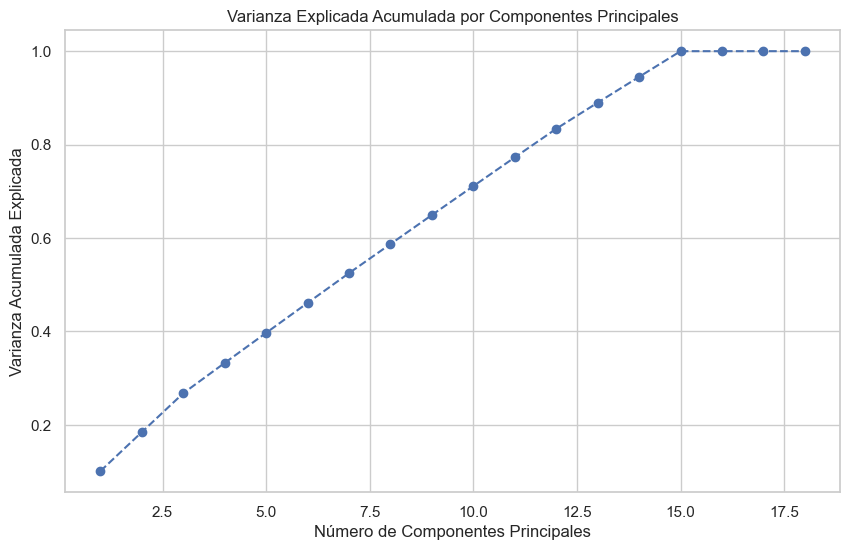

Número de componentes para retener el 95% de la varianza: 15
Primeras 5 filas de los componentes PCA:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,patient_id
0,-0.631326,1.637326,-0.500849,0.282724,-0.386584,0.129734,0.854901,-0.765329,-0.241519,1.339828,0.082897,0.360163,-1.461516,0.180817,-0.787583,0
1,-0.632996,-0.359052,1.754081,0.225861,0.461276,-0.395747,0.472146,0.642429,0.194326,-0.593730,-0.452111,0.899294,1.091933,-0.487863,1.209252,1
2,-0.640074,1.572464,-0.525927,-0.131742,-0.662223,0.668509,0.834851,-0.368863,0.759167,0.198086,-0.367084,-0.377056,-0.234092,-0.149938,-2.101569,2
3,-0.644290,1.691865,-0.512678,0.169524,1.042325,0.769452,-0.476908,-0.610490,-0.188279,-0.482481,0.324525,-0.247035,0.095424,-0.110148,1.125339,3
4,-0.619542,1.640092,-0.509841,-0.192777,0.034600,0.471178,0.786597,0.865001,0.328347,0.831995,0.581223,-0.217523,-1.492840,-1.456612,-0.431756,4



Dimensiones de los componentes PCA: (54966, 16)


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos para PCA
# Excluir columnas no numéricas y las columnas categóricas/reservadas que no deben ingresar a PCA.
drop_cols = [col for col in ['patient_id', 'gender', 'blood_type', 'most_frequent_condition', 'most_frequent_medication'] if col in patient_feature_matrix.columns]
features = patient_feature_matrix.drop(columns=drop_cols)

# Escalar las características numéricas
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features.select_dtypes(include=['number']))

# Aplicar PCA
pca = PCA()
pca.fit(scaled_features)

# Varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_

# Visualizar la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio.cumsum(), marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

# Determinar el número de componentes para retener el 95% de la varianza
num_components = next(i for i, cumulative_variance in enumerate(explained_variance_ratio.cumsum()) if cumulative_variance >= 0.95) + 1
print(f"Número de componentes para retener el 95% de la varianza: {num_components}")

# Aplicar PCA con el número óptimo de componentes
pca_final = PCA(n_components=num_components)
patient_pca_components = pca_final.fit_transform(scaled_features)

patient_pca_df = pd.DataFrame(data=patient_pca_components, columns=[f'PC_{i+1}' for i in range(num_components)])
patient_pca_df['patient_id'] = patient_feature_matrix['patient_id'] # Agregar patient_id para referencia

print("Primeras 5 filas de los componentes PCA:")
display(patient_pca_df.head())
print(f"\nDimensiones de los componentes PCA: {patient_pca_df.shape}")

### Tabla Comparativa de Reducción de Dimensionalidad (PCA)

In [38]:
pca_summary = pd.DataFrame({
    'Componente': range(1, len(explained_variance_ratio) + 1),
    'Varianza Explicada': explained_variance_ratio,
    'Varianza Acumulada Explicada': explained_variance_ratio.cumsum()
})

display(pca_summary.head(num_components))

print(f"La PCA con {num_components} componentes retiene el {pca_summary['Varianza Acumulada Explicada'].iloc[num_components-1]:.2%} de la varianza original.")

# Error de reconstrucción (opcional, para demostrar)
# Para calcular el error de reconstrucción, necesitamos reconstruir los datos originales
# a partir de los componentes seleccionados y luego comparar con los datos escalados originales.

reconstructed_scaled_features = pca_final.inverse_transform(patient_pca_components)

# Calculamos el error cuadrático medio (MSE) como una métrica simple de error de reconstrucción
from sklearn.metrics import mean_squared_error

reconstruction_error = mean_squared_error(scaled_features, reconstructed_scaled_features)
print(f"Error de reconstrucción (Mean Squared Error): {reconstruction_error:.4f}")

,Componente,Varianza Explicada,Varianza Acumulada Explicada
0,1,0.100913,0.100913
1,2,0.083553,0.184466
2,3,0.083233,0.267699
3,4,0.064868,0.332567
4,5,0.064393,0.396960
5,6,0.064113,0.461073
6,7,0.063755,0.524828
7,8,0.062241,0.587069
8,9,0.062205,0.649274
9,10,0.061817,0.711091


La PCA con 15 componentes retiene el 100.00% de la varianza original.
Error de reconstrucción (Mean Squared Error): 0.0000


### Reducción de Dimensionalidad con t-SNE

In [39]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos los componentes de PCA ya calculados (15 componentes) para mejorar el rendimiento de t-SNE
# t-SNE es computacionalmente costoso, por lo que tomamos una muestra si el dataset es muy grande
# En este caso, procesaremos el conjunto completo tras la reducción PCA

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    max_iter=1000 # Ajustado para eficiencia
)

# Ajustar y transformar
patient_tsne_results = tsne.fit_transform(patient_pca_components)

# Crear DataFrame para visualización
patient_tsne_df = pd.DataFrame(
    data=patient_tsne_results,
    columns=['tsne_1', 'tsne_2']
)

# Añadir metadatos para colorear el gráfico
patient_tsne_df['patient_id'] = patient_feature_matrix['patient_id'].values
patient_tsne_df = pd.merge(
    patient_tsne_df,
    patient_feature_matrix[['patient_id', 'gender', 'blood_type']],
    on='patient_id'
)

display(patient_tsne_df.head())

,tsne_1,tsne_2,patient_id,gender,blood_type
0,5.513302,43.891930,0,Male,AB-
1,-88.227005,-12.577060,1,Female,A+
2,-50.365547,102.451820,2,Male,O-
3,-0.189762,66.799431,3,Female,B-
4,11.315228,99.920578,4,Male,B-


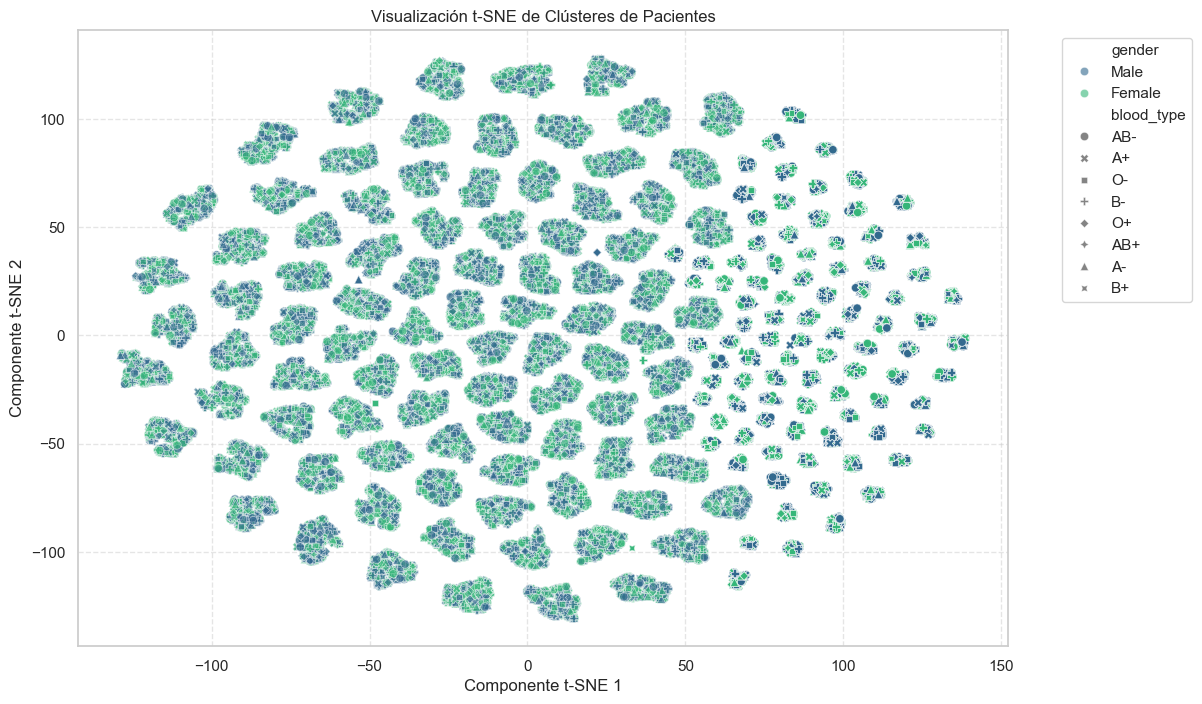

In [40]:
# Visualización de t-SNE
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='gender',
    style='blood_type',
    data=patient_tsne_df,
    palette='viridis',
    alpha=0.6
)

plt.title('Visualización t-SNE de Clústeres de Pacientes')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [41]:
import numpy as np

print(features.shape)
print(features.select_dtypes(include='number').shape)
print(np.linalg.matrix_rank(scaled_features))

(54966, 28)
(54966, 18)
15


### Visualización de Reducción de Dimensionalidad con t-SNE

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar escalado de datos
drop_cols = [col for col in ['patient_id', 'gender', 'blood_type', 'most_frequent_condition', 'most_frequent_medication'] if col in patient_feature_matrix.columns]
features_to_scale = patient_feature_matrix.drop(columns=drop_cols)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale.select_dtypes(include=['number']))

In [43]:
# 2. PCA previo para reducir ruido y mejorar velocidad de t-SNE (usando 15 componentes)
pca_pre = PCA(n_components=15, random_state=42)
pca_features = pca_pre.fit_transform(scaled_features)

In [44]:
# 3. Ejecutar t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    init='pca',
    learning_rate='auto'
)
patient_tsne_components = tsne.fit_transform(pca_features)

In [45]:
# 4. Preparar DataFrame para visualización
patient_tsne_df = pd.DataFrame(data=patient_tsne_components, columns=['TSNE_1', 'TSNE_2'])
patient_tsne_df['patient_id'] = patient_feature_matrix['patient_id'].values

patient_tsne_plot_df = pd.merge(
    patient_tsne_df,
    patient_feature_matrix[['patient_id', 'gender', 'blood_type']],
    on='patient_id',
    how='left'
)

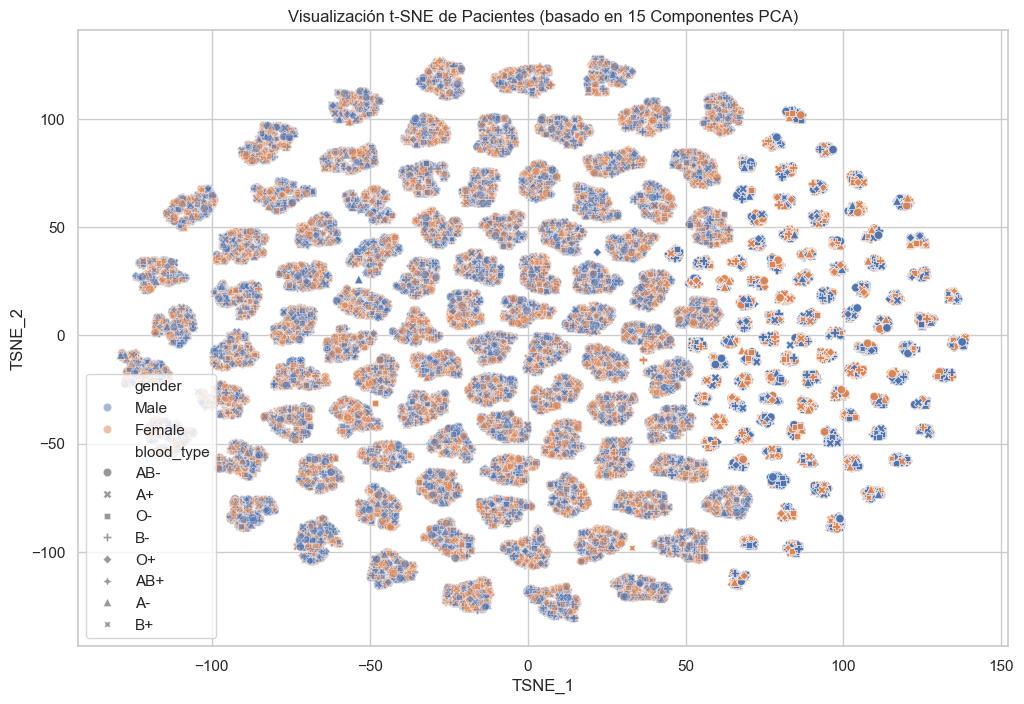

In [46]:
# 5. Graficar
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='gender', style='blood_type',
    data=patient_tsne_plot_df,
    alpha=0.5
)
plt.title('Visualización t-SNE de Pacientes (basado en 15 Componentes PCA)')
plt.grid(True)
plt.show()

### Visualizaciones Avanzadas de Análisis de Datos

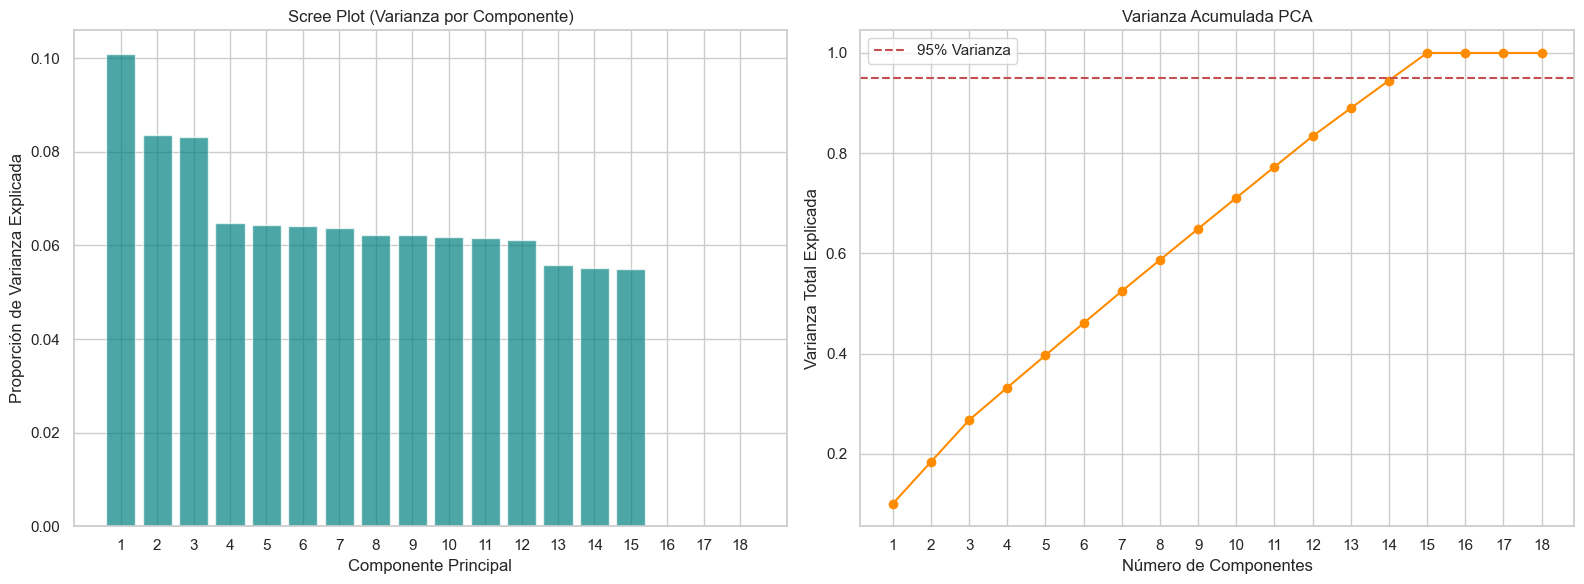

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuramos el estilo
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scree Plot (Varianza Individual)
ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, color='teal', label='Varianza Individual')
ax1.set_title('Scree Plot (Varianza por Componente)')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Proporción de Varianza Explicada')
ax1.set_xticks(range(1, len(explained_variance_ratio) + 1))

# 2. Varianza Acumulada
cum_variance = np.cumsum(explained_variance_ratio)
ax2.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='-', color='darkorange')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza')
ax2.set_title('Varianza Acumulada PCA')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Total Explicada')
ax2.set_xticks(range(1, len(cum_variance) + 1))
ax2.legend()

plt.tight_layout()
plt.show()

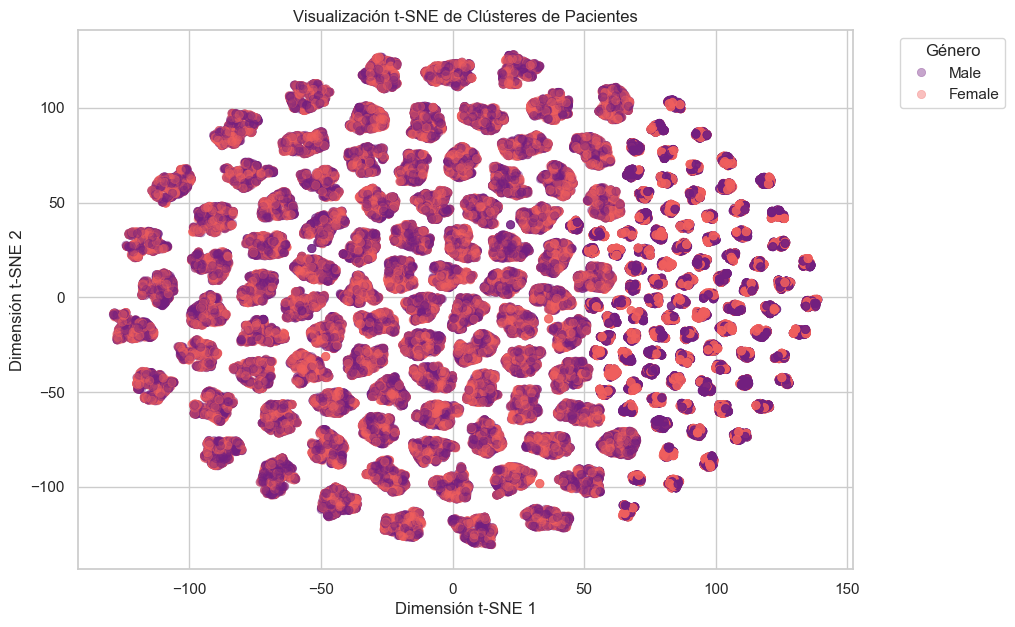

In [48]:
# 3. Scatter Plot t-SNE Optimizado
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='gender',
    data=patient_tsne_plot_df,
    palette='magma',
    alpha=0.4,
    edgecolor=None
)
plt.title('Visualización t-SNE de Clústeres de Pacientes')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

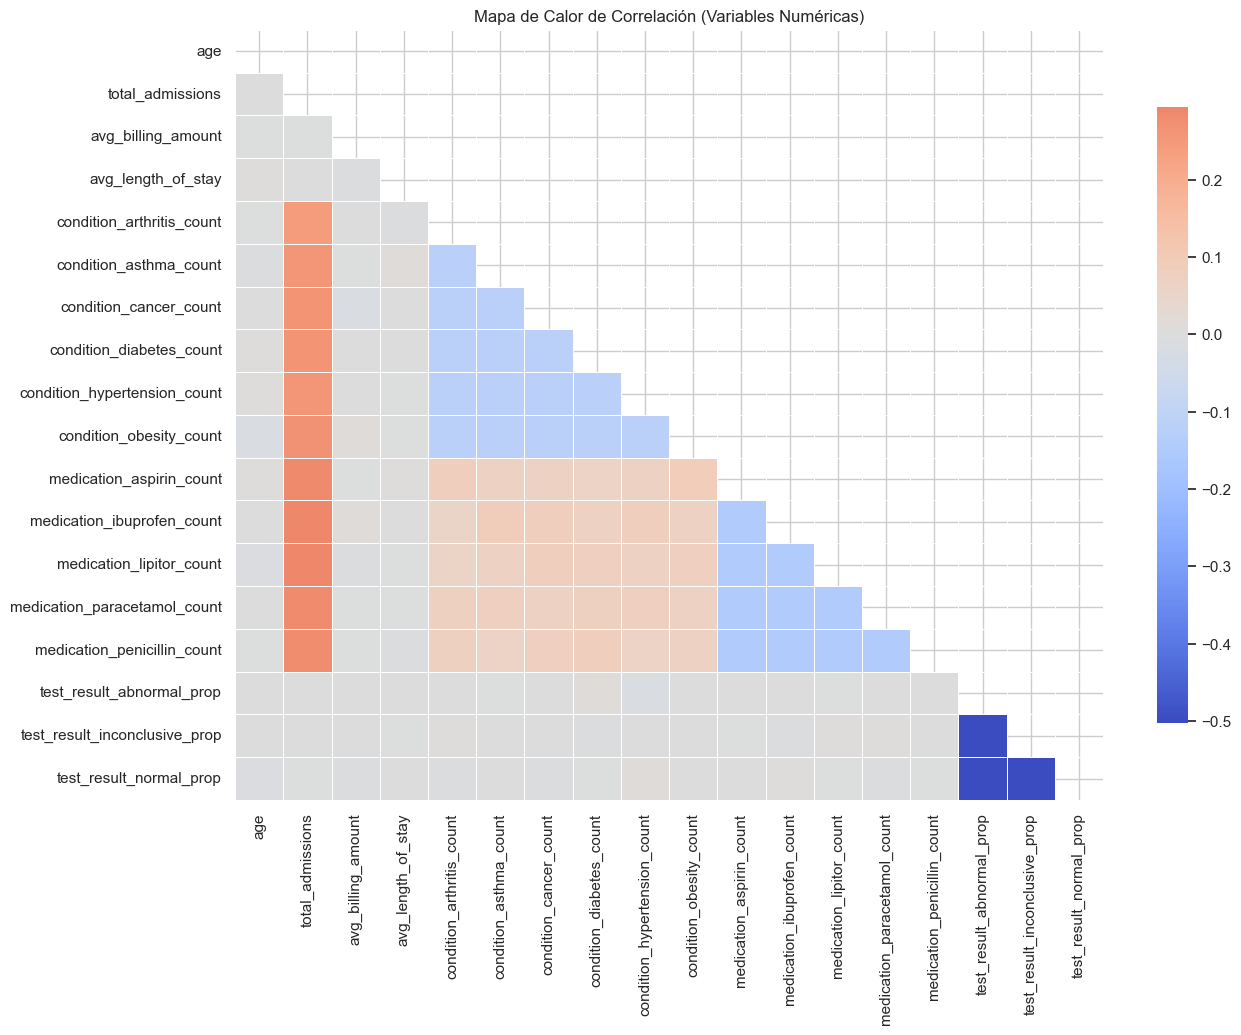

In [49]:
# 4. Heatmap de Correlación de Variables Originales
plt.figure(figsize=(14, 10))
corr_matrix = features.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Mapa de Calor de Correlación (Variables Numéricas)')
plt.show()